# Lab 2: Geostrophic Adjustment

**Driving question:** How does geostrophic balance get established from some initial disturbance, and what governs the nature of this *geostrophic adjustment*?

**Your task:** This notebook already contains a complete model that simulates geostrophic adjustment and horizontal propagating shallow water waves by numerically solving (i.e., integrating) the linearized shallow water equations. Your job is to:
1. Use this model to run experiments by modifying key parameters
2. Create visuals that help you demonstrate the sensitivities of geostrophic adjustment to those changes
3. Write up interpretations in markdown boxes at the bottom of this notebook.

More below on each of these tasks...

**Due date:** complete this notebook and push it to your repo by 11:59 PM, Friday Sept. 18th.

## Model overview

This model numerically solves the shallow water equations of motion for a one-dimensional disturbance on an $f$-plane. Wave propagation and divergent motion manifest in the $x$-dimension. The $v$-wind oscillates through Coriolis deflection, but with no divergence. In this sense, there is no propagation in $y$. The model is linearized: we will neglect nonlinear advection, which significantly simplifies solutions. The equations that the model solves are as follows:

$$
\frac{\partial u}{\partial t}-f_0v=-g\frac{\partial h}{\partial x},
$$

$$
\frac{\partial v}{\partial t}+f_0u=0,
$$

$$
\frac{\partial h}{\partial t}+H\frac{\partial u}{\partial x}=0.
$$

As in class, $u$ and $v$ are the perturbation velocity components, $h$ is the perturbation layer height, $H$ is the base state layer depth, $f_0$ is the Coriolis parameter, and $g$ is gravity.

To kick off disturbances, the model is initialized with an initial Gaussian height anomaly and resting initial-state velocity:

$$
h(0,x)=h_0\exp\left[-\frac{x^2}{2L_0^2}\right],
\quad u(0,x)=v(0,x)=0.
$$

This initial height perturbation requires two input parameters:
1. $L_0$ assumed horizontal length scale (i.e., Gaussian width)
2. $h_0$ amplitude

## Model parameters that can remain unmodified

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm

# Note: most settings below are just the default values.
# Many can be overridden when the model is called further down the notebook.

# Physical constants
G = 9.81                         # m s^-2
OMEGA = 7.2921159e-5             # Earth's rotation rate, s^-1
H = 250.0                        # base state layer depth, m

# Spatial grid
DOMAIN_LENGTH = 20_000_000.0     # 20,000 km
NX = 1000                        # Number of grid points
DX = DOMAIN_LENGTH / NX          # Grid spacing, m
X = (np.arange(NX) - NX // 2) * DX # X-grid, m

# Initial Gaussian disturbance
L_0 = 600_000.0                  # Length scale, i.e., Gaussian width, m
h_0 = 10.0                       # Initial disturbance amplitude, m

# Time integration
DT = 120.0                       # Time step, s
STOP_TIME = 48.0 * 3600.0        # Experiment duration, s
SAVE_EVERY = 5                   # Save output every x time steps

# Print some basic information about the simulation
print(f"Grid spacing: {DX / 1000:.1f} km")
print(f"Grid size: {NX * DX / 1000:.0f} km")
print(f"Experiment duration: {STOP_TIME / 3600:.0f} h")
print(f"Time step: {DT / 60:.1f} min")
print()

# Print some default settings
print(f"Initial disturbance width L_0: {L_0 / 1000:.0f} km")
print(f"Initial disturbance amplitude h_0: {h_0} m")

Grid spacing: 20.0 km
Grid size: 20000 km
Experiment duration: 48 h
Time step: 2.0 min

Initial disturbance width L_0: 600 km
Initial disturbance amplitude h_0: 10.0 m


## Model engine

### Support functions

In [2]:
# Calculate the Coriolis parameter f_0
def coriolis_parameter(latitude_degrees):
    latitude_radians = np.deg2rad(latitude_degrees)
    return 2.0 * OMEGA * np.sin(latitude_radians)

# Calculate the x-gradient using a second-order centered difference scheme
# with periodic boundary conditions
def centered_gradient(field, dx=DX):
    return (np.roll(field, -1, axis=-1) - np.roll(field, 1, axis=-1)) / (2.0 * dx)

# Initially resting fluid with a centered Gaussian height anomaly
def initial_conditions(amplitude=h_0, width=L_0, x=X):
    h = amplitude * np.exp(-0.5 * (x / width) ** 2)
    u = np.zeros_like(h)
    v = np.zeros_like(h)
    return u, v, h

### Main driver functions

In [3]:
# Advance the fields to the next time step with a centered half/full/half-step update
def advance_one_step(u0, v0, h0, dt, f_0, g=G, mean_depth=H, dx=DX):

    # This is where our equations of motion are implemented
    # 
    # The centered half/full/half-step update is a numerical integration scheme that
    # updates the velocity and height fields in a staggered manner.
    # 
    # The first half-step updates the velocity fields using the current height field,
    # then the full step updates the height field using the updated velocity fields,
    # and finally, the second half-step updates the velocity fields again using the
    # new height field.
    # 
    # This approach helps maintain numerical stability and accuracy in the solution.

    du_dt = f_0 * v0 - g * centered_gradient(h0, dx)
    u_half = u0 + 0.5 * dt * du_dt

    dv_dt = -f_0 * u_half
    dh_dt = -mean_depth * centered_gradient(u_half, dx)

    v1 = v0 + dt * dv_dt
    h1 = h0 + dt * dh_dt
    u1 = u_half + 0.5 * dt * (f_0 * v1 - g * centered_gradient(h1, dx))

    return u1, v1, h1

# Integrate one experiment and return a dictionary of saved NumPy arrays
def integrate_case(
    f_0,                   # Coriolis setting (required argument)
    amplitude=h_0,         # Perturbation amplitude (optional argument with a default setting if blank)
    width=L_0,             # Length scale (optional argument)
    stop_time=STOP_TIME,   # Experiment duration (optional argument)
    dt=DT,                 # Time step (optional argument)
    save_every=SAVE_EVERY, # Save output every x time steps (optional argument)
):
    # The model parameters for a given integration are established by the arguments passed
    # into the function. As the comments above imply, a mix of required and optional
    # arguments are used. Optional arguments are those that have default values provided
    # in the function definition. As written, f_0 is a required input, while all other
    # parameters use default values unless explicitly specified in the function call.

    # Establish model initial state
    u, v, h = initial_conditions(amplitude=amplitude, width=width)

    n_steps = int(round(stop_time / dt))

    # Main model time loop
    # Variables are saved in lists at specified intervals (using the % "modulo" operator)
    times, u_saved, v_saved, h_saved = [], [], [], []
    for step in range(n_steps + 1):
        if step % save_every == 0:
            times.append(step * dt)
            u_saved.append(u.copy())
            v_saved.append(v.copy())
            h_saved.append(h.copy())

        if step < n_steps:
            u, v, h = advance_one_step(u, v, h, dt, f_0)

    # Return a dictionary of saved NumPy arrays and parameter settings
    return {
        "time": np.asarray(times),
        "x": X.copy(),
        "u": np.asarray(u_saved),
        "v": np.asarray(v_saved),
        "h": np.asarray(h_saved),
        "f_0": float(f_0),
        "amplitude": float(amplitude),
        "width": float(width),
    }

## YOUR TASK STARTS HERE

The function `integrate_case()` in the above code block is the main model *driver function.* As in most atmospheric models, the driver is the parent function that calls all other tasks to run the model. In our model, this driver function does the following:
1. Establishes the parameters for the model run
2. Creates the model initial state
3. Loops over time to integrate the equations
4. Writes out the model output as a dictionary

As noted in the comments inside that function, the parameters for a given model run are established through the function's arguments. Only one argument ($f_0$) is required, while all others are set to default values unless specified otherwise when the function is called.

Your task is to run the model for a set of parameter modifications across two key dimensions: $f_0$ and $L_0$ (*width* in the function call). Compare at least four values of $f_0$, including zero, while holding $L_0$ fixed. Separately, compare at least four values of $L_0$ at a fixed, nonzero value of $f_0$. You may reuse a common baseline experiment. Keep track of any parameters you change and hold constant.

Examples of how to run the model by calling this function are provided below. In the loop example, the code populates `lists` and `dictionaries`, which are two distinct powerful ways to store collections of information. See [this page](https://www.geeksforgeeks.org/python/difference-between-list-and-dictionary-in-python/) for a quick overview of their usage and differences.

### Example run code

I suggest leaving this code unchanged for reference, and writing your own in the block below (copying anything that may be helpful from this one).

In [4]:
# Example model run for a given latitude and f_0-setting
# All other settings are left to default values
latitude = 15.0
f_0 = coriolis_parameter(latitude)
single_run_f15deg = integrate_case(f_0)
# Print the dictionary keys and some parameter values
print(single_run_f15deg.keys())
print(f"Coriolis parameter: {single_run_f15deg['f_0']}")
print(f"h_0: {single_run_f15deg['amplitude']}")
print(f"L_0: {single_run_f15deg['width']}")
print()

# Example model run for a given latitude and f_0-setting with a smaller L_0 value
single_run_f15_modL0 = integrate_case(f_0, width=100000.0)
# Print the dictionary keys and some parameter values
print(single_run_f15_modL0.keys())
print(f"Coriolis parameter: {single_run_f15_modL0['f_0']}")
print(f"h_0: {single_run_f15_modL0['amplitude']}")
print(f"L_0: {single_run_f15_modL0['width']}")
print()

# Use a loop to iteratively run a set of 4 experiments and store their parameter settings
case_names = [] # initialize a list
run_params = [] # initialize a list
runs = {} # initialize a dictionary; each new entry has a "key" (e.g., a name)
for lat in [0, 15.0, 35.0, 60.0]:
    f = coriolis_parameter(lat)
    case_label = f"{lat}°N"
    print(f"Integrating {case_label} ...")
    case_names.append(case_label)
    run_params.append({"label": case_label, "latitude": lat, "f_0": f, "amplitude": h_0, "width": L_0})
    runs[case_label] = integrate_case(f, amplitude=h_0, width=L_0)

dict_keys(['time', 'x', 'u', 'v', 'h', 'f_0', 'amplitude', 'width'])
Coriolis parameter: 3.774676948029817e-05
h_0: 10.0
L_0: 600000.0

dict_keys(['time', 'x', 'u', 'v', 'h', 'f_0', 'amplitude', 'width'])
Coriolis parameter: 3.774676948029817e-05
h_0: 10.0
L_0: 100000.0

Integrating 0°N ...
Integrating 15.0°N ...
Integrating 35.0°N ...
Integrating 60.0°N ...


### Your new run code

In [5]:
#looping through four different latitudes used to calculate the coriolis parameter
lat_case_names = [] # initialize a list
lat_run_params = [] # initialize a list
lat_runs = {} # initialize a dictionary; each new entry has a "key" (e.g., a name)
for lat in [0, 30.0, 45.0, 60.0]:
    f = coriolis_parameter(lat)
    case_label = f"{lat}°N"
    print(f"Integrating {case_label} ...")
    lat_case_names.append(case_label)
    lat_run_params.append({"label": case_label, "latitude": lat, "f_0": f, "amplitude": h_0, "width": L_0})
    lat_runs[case_label] = integrate_case(f, amplitude=h_0, width=L_0)

#looping through four different initial disturbancewidths
width_case_names = [] # initialize a list
width_run_params = [] # initialize a list
width_runs = {} # initialize a dictionary; each new entry has a "key" (e.g., a name)
for width in [1000, 10000, 100000, 1000000]:
    f = coriolis_parameter(45.0)
    case_label = f"{width} m"
    print(f"Integrating {case_label} ...")
    width_case_names.append(case_label)
    width_run_params.append({"label": case_label, "latitude": 45.0, "f_0": f, "amplitude": h_0, "width": width})
    width_runs[case_label] = integrate_case(f, amplitude=h_0, width=width)


Integrating 0°N ...
Integrating 30.0°N ...
Integrating 45.0°N ...
Integrating 60.0°N ...
Integrating 1000 m ...
Integrating 10000 m ...
Integrating 100000 m ...
Integrating 1000000 m ...


## Plots

The plotting task for this assignment provides a lot of latitude (zing). But your visuals should accomplish the following:
- Provide an adequate sense of how the geostrophic adjustment (GA) process works and evolves in general in this model by showing the evolution of height and both velocity components for a rotating (i.e., $f_0\ne0$) experiment
- Demonstrate how the GA process differs as a function of varied $f_0$ and $L_0$ (it is probably ideal to depict those sensitivities separately).

Also, in all plots, be sure to label axes with units and identify cases (any parameter settings as needed) and times. Use consistent axis limits or color scales where practical when direct comparisons are important.

Here are some example plot ideas, which may be helpful.
- multipanel for a single simulation: a set of snapshots of the perturbation height and wind fields at several times through the duration of a given simulation
- multipanel for multiple simulations: plot a given variable at multiple time steps for a given simulation in each panel
- Hovmöller diagrams (time vs. $x$) with a given perturbation variable shaded, which could be shown as a multipanel for different variables or different simulations (using the same variable)

### Figure 1

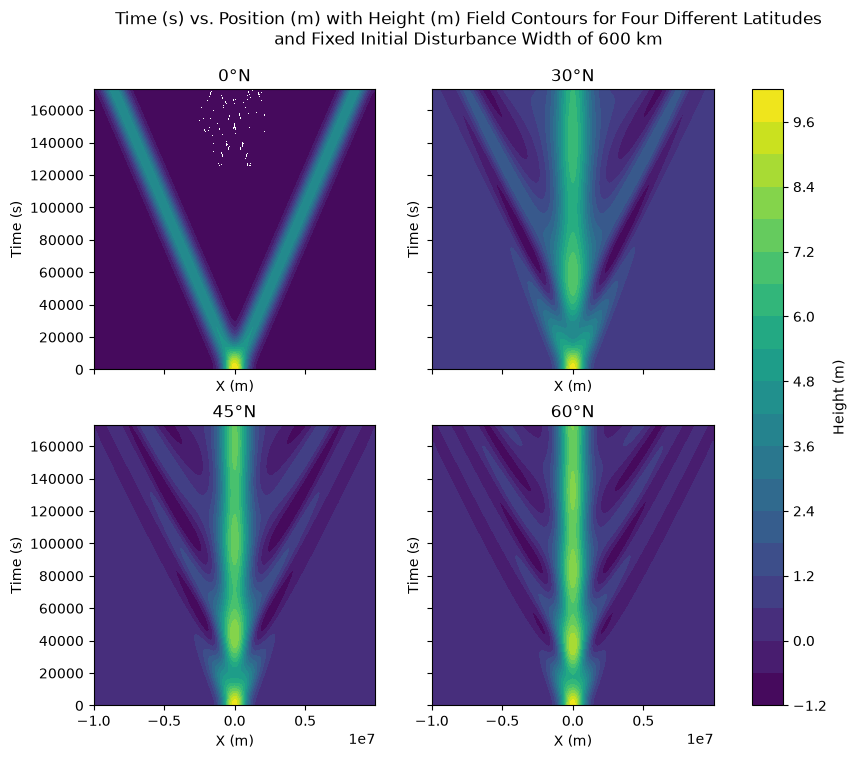

In [6]:
#make a height perturbation hovmoller multiplot figure for different latitudes and fixed initial disturbance width of 600 km
fig, ax = plt.subplots(2,2, sharex=True, sharey=True, figsize=(10, 8))
ax[0,0].contourf(lat_runs['0°N']['x'], lat_runs['0°N']['time'], lat_runs['0°N']['h'], cmap='viridis', levels=20)
ax[0,0].set_title('0°N')
ax[0,0].set_ylabel('Time (s)')
ax[0,0].set_xlabel('X (m)')

ax[0,1].contourf(lat_runs['30.0°N']['x'], lat_runs['30.0°N']['time'], lat_runs['30.0°N']['h'], cmap='viridis', levels=20)
ax[0,1].set_title('30°N')
ax[0,1].set_xlabel('X (m)')
ax[0,1].set_ylabel('Time (s)')

ax[1,0].contourf(lat_runs['45.0°N']['x'], lat_runs['45.0°N']['time'], lat_runs['45.0°N']['h'], cmap='viridis', levels=20)
ax[1,0].set_title('45°N')
ax[1,0].set_xlabel('X (m)')
ax[1,0].set_ylabel('Time (s)')

ax[1,1].contourf(lat_runs['60.0°N']['x'], lat_runs['60.0°N']['time'], lat_runs['60.0°N']['h'], cmap='viridis', levels=20)
ax[1,1].set_title('60°N')
ax[1,1].set_xlabel('X (m)')
ax[1,1].set_ylabel('Time (s)')


fig.colorbar(ax[1,1].collections[0], ax=ax, orientation='vertical', label='Height (m)')
fig.suptitle('Time (s) vs. Position (m) with Height (m) Field Contours for Four Different Latitudes\nand Fixed Initial Disturbance Width of 600 km', fontsize=12);


### Figure 2

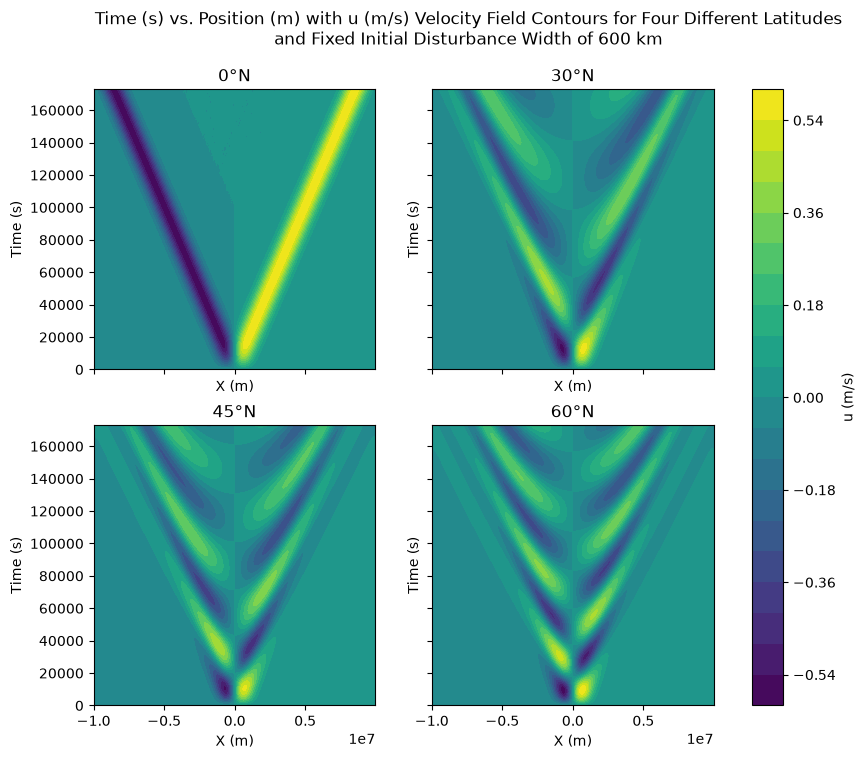

In [7]:
#make a u velocity hovmoller multiplot figure for different latitudes and fixed initial disturbance width of 600 km
fig, ax = plt.subplots(2,2, sharex=True, sharey=True, figsize=(10, 8))
ax[0,0].contourf(lat_runs['0°N']['x'], lat_runs['0°N']['time'], lat_runs['0°N']['u'], cmap='viridis', levels=20)
ax[0,0].set_title('0°N')
ax[0,0].set_ylabel('Time (s)')
ax[0,0].set_xlabel('X (m)')

ax[0,1].contourf(lat_runs['30.0°N']['x'], lat_runs['30.0°N']['time'], lat_runs['30.0°N']['u'], cmap='viridis', levels=20)
ax[0,1].set_title('30°N')
ax[0,1].set_xlabel('X (m)')
ax[0,1].set_ylabel('Time (s)')

ax[1,0].contourf(lat_runs['45.0°N']['x'], lat_runs['45.0°N']['time'], lat_runs['45.0°N']['u'], cmap='viridis', levels=20)
ax[1,0].set_title('45°N')
ax[1,0].set_xlabel('X (m)')
ax[1,0].set_ylabel('Time (s)')

ax[1,1].contourf(lat_runs['60.0°N']['x'], lat_runs['60.0°N']['time'], lat_runs['60.0°N']['u'], cmap='viridis', levels=20)
ax[1,1].set_title('60°N')
ax[1,1].set_xlabel('X (m)')
ax[1,1].set_ylabel('Time (s)')


fig.colorbar(ax[1,1].collections[0], ax=ax, orientation='vertical', label='u (m/s)')
fig.suptitle('Time (s) vs. Position (m) with u (m/s) Velocity Field Contours for Four Different Latitudes\nand Fixed Initial Disturbance Width of 600 km', fontsize=12);


### Figure 3

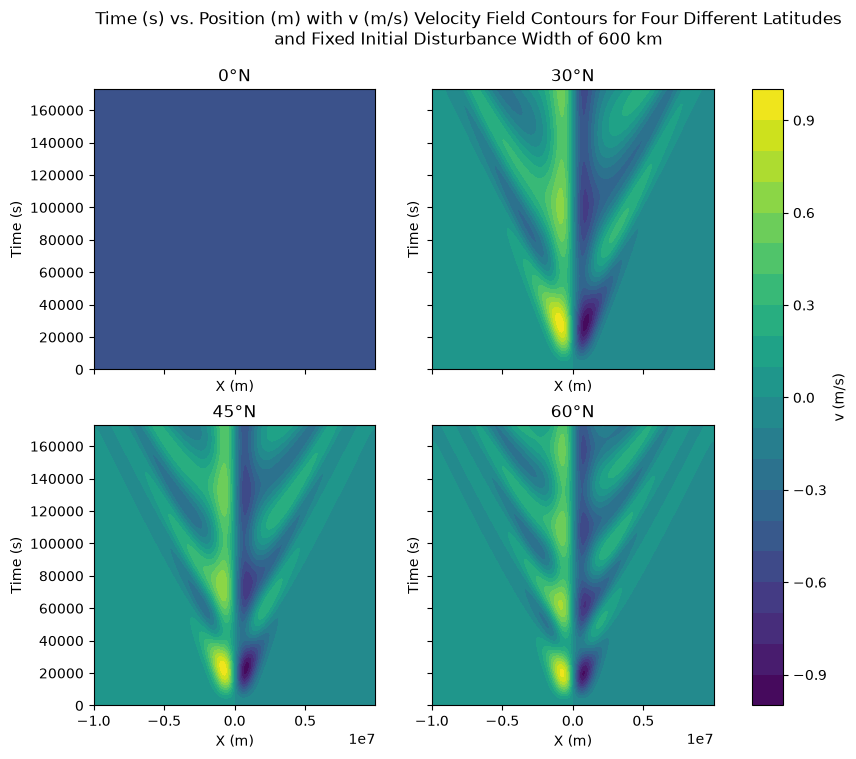

In [8]:
#make a v velocity hovmoller multiplot figure for different latitudes and fixed initial disturbance width of 600 km
fig, ax = plt.subplots(2,2, sharex=True, sharey=True, figsize=(10, 8))
ax[0,0].contourf(lat_runs['0°N']['x'], lat_runs['0°N']['time'], lat_runs['0°N']['v'], cmap='viridis', levels=20)
ax[0,0].set_title('0°N')
ax[0,0].set_ylabel('Time (s)')
ax[0,0].set_xlabel('X (m)')

ax[0,1].contourf(lat_runs['30.0°N']['x'], lat_runs['30.0°N']['time'], lat_runs['30.0°N']['v'], cmap='viridis', levels=20)
ax[0,1].set_title('30°N')
ax[0,1].set_xlabel('X (m)')
ax[0,1].set_ylabel('Time (s)')

ax[1,0].contourf(lat_runs['45.0°N']['x'], lat_runs['45.0°N']['time'], lat_runs['45.0°N']['v'], cmap='viridis', levels=20)
ax[1,0].set_title('45°N')
ax[1,0].set_xlabel('X (m)')
ax[1,0].set_ylabel('Time (s)')

ax[1,1].contourf(lat_runs['60.0°N']['x'], lat_runs['60.0°N']['time'], lat_runs['60.0°N']['v'], cmap='viridis', levels=20)
ax[1,1].set_title('60°N')
ax[1,1].set_xlabel('X (m)')
ax[1,1].set_ylabel('Time (s)')


fig.colorbar(ax[1,1].collections[0], ax=ax, orientation='vertical', label='v (m/s)')
fig.suptitle('Time (s) vs. Position (m) with v (m/s) Velocity Field Contours for Four Different Latitudes\nand Fixed Initial Disturbance Width of 600 km', fontsize=12);


### Figure 4

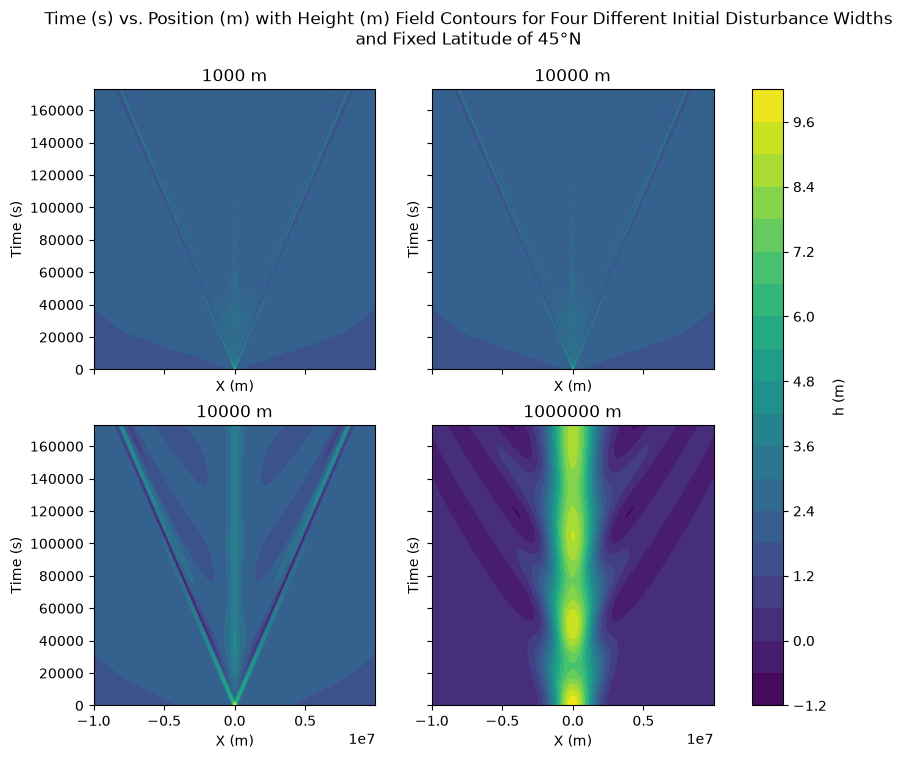

In [9]:
#make a height perturbation hovmoller multiplot figure for different initial disturbance widths and fixed latitude of 45°N
fig, ax = plt.subplots(2,2, sharex=True, sharey=True, figsize=(10, 8))
ax[0,0].contourf(width_runs['1000 m']['x'], width_runs['1000 m']['time'], width_runs['1000 m']['h'], cmap='viridis', levels=20)
ax[0,0].set_title('1000 m')
ax[0,0].set_ylabel('Time (s)')
ax[0,0].set_xlabel('X (m)')

ax[0,1].contourf(width_runs['10000 m']['x'], width_runs['10000 m']['time'], width_runs['10000 m']['h'], cmap='viridis', levels=20)
ax[0,1].set_title('10000 m')
ax[0,1].set_xlabel('X (m)')
ax[0,1].set_ylabel('Time (s)')

ax[1,0].contourf(width_runs['100000 m']['x'], width_runs['100000 m']['time'], width_runs['100000 m']['h'], cmap='viridis', levels=20)
ax[1,0].set_title('10000 m')
ax[1,0].set_xlabel('X (m)')
ax[1,0].set_ylabel('Time (s)')

ax[1,1].contourf(width_runs['1000000 m']['x'], width_runs['1000000 m']['time'], width_runs['1000000 m']['h'], cmap='viridis', levels=20)
ax[1,1].set_title('1000000 m')
ax[1,1].set_xlabel('X (m)')
ax[1,1].set_ylabel('Time (s)')


fig.colorbar(ax[1,1].collections[0], ax=ax, orientation='vertical', label='h (m)')
fig.suptitle('Time (s) vs. Position (m) with Height (m) Field Contours for Four Different Initial Disturbance Widths\nand Fixed Latitude of 45°N', fontsize=12);


### Figure 5

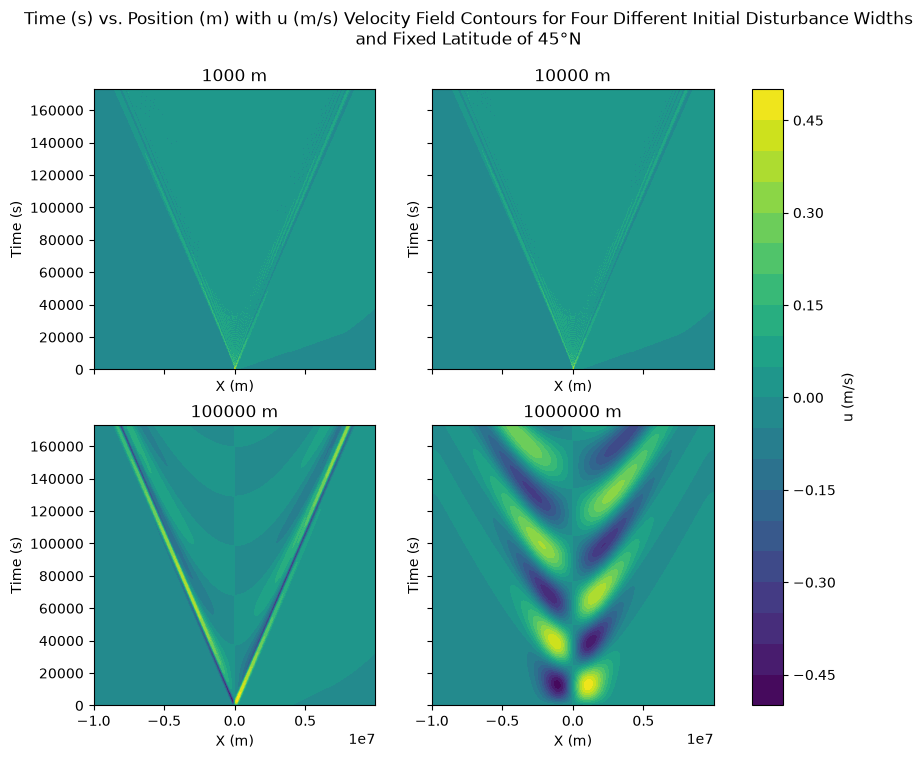

In [10]:
#make a u velocity hovmoller multiplot figure for different initial disturbance widths and fixed latitude of 45°N
fig, ax = plt.subplots(2,2, sharex=True, sharey=True, figsize=(10, 8))
ax[0,0].contourf(width_runs['1000 m']['x'], width_runs['1000 m']['time'], width_runs['1000 m']['u'], cmap='viridis', levels=20)
ax[0,0].set_title('1000 m')
ax[0,0].set_ylabel('Time (s)')
ax[0,0].set_xlabel('X (m)')

ax[0,1].contourf(width_runs['10000 m']['x'], width_runs['10000 m']['time'], width_runs['10000 m']['u'], cmap='viridis', levels=20)
ax[0,1].set_title('10000 m')
ax[0,1].set_xlabel('X (m)')
ax[0,1].set_ylabel('Time (s)')

ax[1,0].contourf(width_runs['100000 m']['x'], width_runs['100000 m']['time'], width_runs['100000 m']['u'], cmap='viridis', levels=20)
ax[1,0].set_title('100000 m')
ax[1,0].set_xlabel('X (m)')
ax[1,0].set_ylabel('Time (s)')

ax[1,1].contourf(width_runs['1000000 m']['x'], width_runs['1000000 m']['time'], width_runs['1000000 m']['u'], cmap='viridis', levels=20)
ax[1,1].set_title('1000000 m')
ax[1,1].set_xlabel('X (m)')
ax[1,1].set_ylabel('Time (s)')


fig.colorbar(ax[1,1].collections[0], ax=ax, orientation='vertical', label='u (m/s)')
fig.suptitle('Time (s) vs. Position (m) with u (m/s) Velocity Field Contours for Four Different Initial Disturbance Widths\nand Fixed Latitude of 45°N', fontsize=12);


### Figure 6

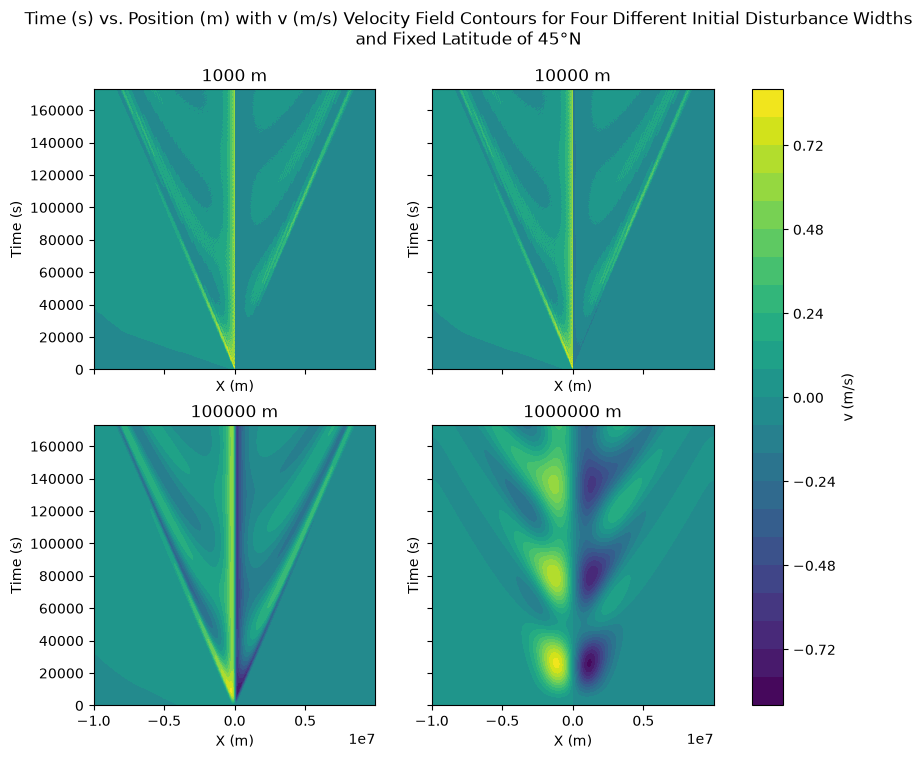

In [11]:
#make a v velocity hovmoller multiplot figure for different initial disturbance widths and fixed latitude of 45°N
fig, ax = plt.subplots(2,2, sharex=True, sharey=True, figsize=(10, 8))
ax[0,0].contourf(width_runs['1000 m']['x'], width_runs['1000 m']['time'], width_runs['1000 m']['v'], cmap='viridis', levels=20)
ax[0,0].set_title('1000 m')
ax[0,0].set_ylabel('Time (s)')
ax[0,0].set_xlabel('X (m)')

ax[0,1].contourf(width_runs['10000 m']['x'], width_runs['10000 m']['time'], width_runs['10000 m']['v'], cmap='viridis', levels=20)
ax[0,1].set_title('10000 m')
ax[0,1].set_xlabel('X (m)')
ax[0,1].set_ylabel('Time (s)')

ax[1,0].contourf(width_runs['100000 m']['x'], width_runs['100000 m']['time'], width_runs['100000 m']['v'], cmap='viridis', levels=20)
ax[1,0].set_title('100000 m')
ax[1,0].set_xlabel('X (m)')
ax[1,0].set_ylabel('Time (s)')

ax[1,1].contourf(width_runs['1000000 m']['x'], width_runs['1000000 m']['time'], width_runs['1000000 m']['v'], cmap='viridis', levels=20)
ax[1,1].set_title('1000000 m')
ax[1,1].set_xlabel('X (m)')
ax[1,1].set_ylabel('Time (s)')


fig.colorbar(ax[1,1].collections[0], ax=ax, orientation='vertical', label='v (m/s)')
fig.suptitle('Time (s) vs. Position (m) with v (m/s) Velocity Field Contours for Four Different Initial Disturbance Widths\nand Fixed Latitude of 45°N', fontsize=12);


### Figure 7

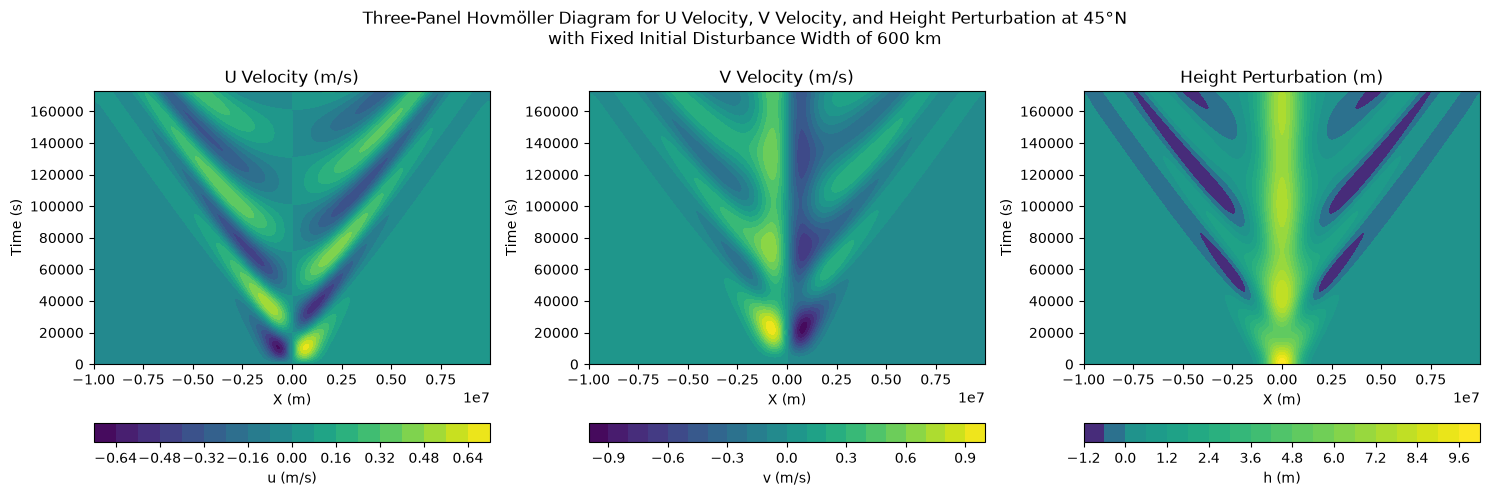

In [12]:
# making a multiplot figure comparing u velocity, v velocity, and height perturbation for a fixed latitude of 45°N and initial disturbance width of 600 km
fig, ax = plt.subplots(1, 3, figsize=(15, 5))

im1 = ax[0].contourf(lat_runs['45.0°N']['x'], lat_runs['45.0°N']['time'], lat_runs['45.0°N']['u'], cmap='viridis', levels=20)
ax[0].set_title('U Velocity (m/s)')
ax[0].set_ylabel('Time (s)')
ax[0].set_xlabel('X (m)')
plt.colorbar(im1, ax=ax[0], orientation='horizontal', label='u (m/s)')

im2 = ax[1].contourf(lat_runs['45.0°N']['x'], lat_runs['45.0°N']['time'], lat_runs['45.0°N']['v'], cmap='viridis', levels=20)
ax[1].set_title('V Velocity (m/s)')
ax[1].set_xlabel('X (m)')
ax[1].set_ylabel('Time (s)')
plt.colorbar(im2, ax=ax[1], orientation='horizontal', label='v (m/s)')

norm_h = TwoSlopeNorm(vmin=lat_runs["45.0°N"]["h"].min(), vcenter=0.0, vmax=lat_runs["45.0°N"]["h"].max())
im3 = ax[2].contourf(lat_runs['45.0°N']['x'], lat_runs['45.0°N']['time'], lat_runs['45.0°N']['h'], cmap='viridis', levels=20, norm=norm_h)
ax[2].set_title('Height Perturbation (m)')
ax[2].set_xlabel('X (m)')
ax[2].set_ylabel('Time (s)')
plt.colorbar(im3, ax=ax[2], orientation='horizontal', label='h (m)')

fig.suptitle("Three-Panel Hovmöller Diagram for U Velocity, V Velocity, and Height Perturbation at 45°N\nwith Fixed Initial Disturbance Width of 600 km", fontsize=12)
plt.tight_layout()
plt.show()

## Diagnostics

For each experiment, diagnose numerical values of $L_D$, $Bu$, and $Ro$ in a table or clearly labeled output. These will be useful for your interpretations below.
$$
L_D=\frac{\sqrt{gH}}{|f_0|},\qquad
Bu=\left(\frac{L_D}{L_0}\right)^2,\qquad
Ro=\frac{U}{|f_0|L_0},\qquad
U=\max_{x,t}\sqrt{u^2+v^2}.
$$
where $U$ is the maximum modeled speed over all saved positions and times; use consistent units in the calculations and be sure to label any units used as needed. Note that some of these metrics are invalid for $f_0=0$ (you can report NaN for those).

In [13]:
#defining functions to calculate the Rossby radius of deformation, Burger number, Rossby number, and maximum modeled speed
def calc_LD(f_0, g=G, H=H):
    return np.sqrt(g * H) / f_0

def calc_Bu(LD, L_0=L_0):
    return (LD / L_0) ** 2

def calc_Ro(U, f_0, L_0=L_0):
    return U / (f_0 * L_0)

def calc_U(u, v):
    return np.sqrt(u**2 + v**2)


In [14]:
#looping through the four different latitudes used to calculate the coriolis parameter, Burger number, Rossby number,
#and characteristic velocity while keeping the initial disturbance width the same
f_experiment_calculations = []
for key in lat_runs.keys():
    specific_f_calc = []
    f_0 = lat_runs[key]['f_0']
    u = np.max(lat_runs[key]['u'])
    v = np.max(lat_runs[key]['v'])
    specific_f_calc.append(f_0)


    U = calc_U(u, v)
    specific_f_calc.append(U)

    if f_0 == 0: #marking metrics that are invalid for no coriolis effect (f_0 = 0)
        specific_f_calc.append(0)
        specific_f_calc.append(0)
        specific_f_calc.append(0)

    if f_0 != 0:
        LD = calc_LD(f_0)
        specific_f_calc.append(LD)
        
        Ro = calc_Ro(U, f_0)
        specific_f_calc.append(Ro)

        Bu = calc_Bu(LD)
        specific_f_calc.append(Bu)
    f_experiment_calculations.append(specific_f_calc)


print(f"{'Coriolis parameter':<22} | {'characteristic velocity':<15} | {'Rossby radius of deformation':<30} | {'Rossby number':<20} |{'Burger number':<20}")
print("-" * 123)

for row in f_experiment_calculations:
    print(f"{row[0]:<22} | {row[1]:<23} | {row[2]:<30} | {row[3]:<20} | {row[4]:<20}")



Coriolis parameter     | characteristic velocity | Rossby radius of deformation   | Rossby number        |Burger number       
---------------------------------------------------------------------------------------------------------------------------
0.0                    | 0.9904412668355288      | 0                              | 0                    | 0                   
7.292115899999999e-05  | 1.2302743337789246      | 679126.9192204904              | 0.028118823824027188 | 1.2811482566942067  
0.00010312609204176488 | 1.1662369032847937      | 480215.2498671374              | 0.018848073592802637 | 0.6405741283471034  
0.0001263031523348085  | 1.0959972209959867      | 392094.10962587135             | 0.014462521332414064 | 0.4270494188980689  


In [15]:
#looping through the four different initial disturbance widths used to calculate the Burger number, Rossby number,
# and characteristic velocity while keeping the latitude constant at 45°N
l0_experiment_calculations = []
for key in width_runs.keys():
    specific_l_calc = []
    f_0 = width_runs[key]['f_0']
    u = np.max(width_runs[key]['u'])
    v = np.max(width_runs[key]['v'])
    specific_l0 = width_runs[key]['width']
    specific_l_calc.append(key)

    U = calc_U(u, v)
    specific_l_calc.append(U)

    if f_0 == 0:
        specific_l_calc.append(0)
        specific_l_calc.append(0)

    if f_0 != 0:
        LD = calc_LD(f_0)
        specific_l_calc.append(LD)
        
        Ro = calc_Ro(U, f_0, L_0=specific_l0) #need to change the argument to include the initial disturbance width L_0
        specific_l_calc.append(Ro)

        Bu = calc_Bu(LD, L_0=specific_l0) #need to change the argument to include the initial disturbance width L_0
        specific_l_calc.append(Bu)

    l0_experiment_calculations.append(specific_l_calc)

print(f"{'Initial disturbance width':<25} | {'characteristic velocity':<15} | {'Rossby radius of deformation':<30} | {'Rossby number':<20} |{'Burger number':<20}")
print("-" * 123)

for row in l0_experiment_calculations:
    print(f"{row[0]:<25} | {row[1]:<23} | {row[2]:<30} | {row[3]:<20} | {row[4]:<20}")

Initial disturbance width | characteristic velocity | Rossby radius of deformation   | Rossby number        |Burger number       
---------------------------------------------------------------------------------------------------------------------------
1000 m                    | 1.0978361425859477      | 480215.2498671374              | 10.645571075662762   | 230606.68620495722  
10000 m                   | 1.0975156136956776      | 480215.2498671374              | 1.0642462949640294   | 2306.066862049572   
100000 m                  | 1.0649902993079006      | 480215.2498671374              | 0.10327069301497353  | 23.06066862049572   
1000000 m                 | 0.9530429046299633      | 480215.2498671374              | 0.009241530302961464 | 0.23060668620495722 


## Interpretations

Address each of the following prompts in the markdown cell below them. In each response, be specific and reference your plots to support your points.

1. For a rotating experiment (i.e., $f_0 \ne 0$), describe the geostrophic adjustment process: explain what initiates motion, how the height and velocity fields subsequently evolve, and what evidence suggests that the central disturbance approaches geostrophic balance. Distinguish the central remnant from the outward-propagating waves.

For my non-rotating experiment, I chose a latitude of 45°N to best represent the geostrophic adjustment process in the midlatitudes and this experiment is shown in a three-panel Hovmoller diagram with u velocity, v velocity, and height. Motion is initiated by the presence of a disturbance in the height field. Because initial velocities are zero, then there is no coriolis force at $t=0$. As a result of a positive height perturbation, gravity acts to initiate negative buoyancy in an attempt to resolve the perturbation. However, this restorative force overshoots and produces outward motion from the disturbance that manifests as an oscillation and initial accelerations are driving by just the pressure gradient force. As time progresses and the parcel accelerates from the initial disturbance, the magnitude of the coriolis force increases and deflects the parcel away from the initial disturbance. In the u velocity figure with fixed $f_0$, we can see the arbitrary parcels being deflected from the initial position at $t=0$. When looking at the height field, the maximum perturbation height was at the initial disturbance. As time progresses, one can observe the oscillations propagating outward from the central disturbance. As x increases (or decreases) with time, the pertubation height alternates between both positive and negative magnitudes.

When looking at both the u and velocity plots, it becomes evident that the disturbance reaches geostrophic balance towards the end of the simulation. One of the key properties of geostrophic balance is that the flow is moving at a constant rate and not accelerating. Near x=0 where the disturbance occured, we can initially see rapid changes in velocity as indicated by the minimal distance between filled contours. Following the same position, the distance between velocity contours increases with time, indicating that accelerations are occuring less near the central disturbance. At $t=160000$ seconds, both the u and v velocity components stabilized to a constant value near the central disturbance. Therefore, geostrophy is achieved and we can say that the pressure gradient force and coriolis force reached balance at the end of the simulation.

Despite the fact that the perturbation produced outward-propagating waves and reached geostrophic balance, a height remnant still lingered at the location of the initial disturbance. Because I picked a latitude value where coriolis is relatively large, the Rossby radius of deformation is smaller. The radius of deformation is the distance that height adjusts to reach it's steady state (in this case, geostrophic balance). In this experiment, $L_D$ was calculated to be 480215 m, while the initial disturbance width was 600000 m. Since $L_0>>L_D$, the height of the perturbation only needs to change slightly before the coriolis force balances PGF for geostrophy. 

2. Discuss the effects of changing $f_0$ and $L_0$ separately. What changes in the evolution and the remnant height anomaly at the center? Include the nonrotating case in your discussion. Incorporate $Ro$, $L_D$, and $Bu$ into your interpretations.

For figure 1, I created a 4-panel Hovmoller plot comparing height perturbations for four different values of $f_0$. In all cases, each height perturbation is centered at 10 m at t=0. For all non-zero values of $f_0$, a remnant height anomaly is present in the center of the domain as time progresses. For the non-rotating experiment, there is no remnant height anomaly left at the center. The presence and magnitude of the remnant height anomaly is directly related to the magnitude of rotation. In the table above, the Rossby radius of deformation decreases as $f_0$ increases for the rotating cases. As $L_D$ decreased with $f_0$, then the distance between the deformation radius and initial disturbance width increased. Following the argument made in question 1, the remnant height anomaly will have a larger magnitude at the final time as $f_0$ increases due to this difference. Looking at figure 1, one can observe a value of 6.6 m at 30°N, 7.8 m at 45°N, and 9.0 m at 60°N. In the non-rotating case, there is no remant height anomaly in the center because there is no Rossby radius of deformation. The Burger number, $B_u$ can also be used as a way to directly compare the role of rotation. In the table above, the increase in $L_D$ with $f_0$ will decrease the Burger number. With values less than 1, then rotation will dominate which we also saw with the deformation radius in the rotating experiments. Without rotation, a Burger number cannot be calculated for the non-rotating case. When considering how the Rossby number varies across the experiments, the calculation is a function of characteristic velocity and coriolis force. For the rotating cases, the characteristic velocity is similar among latitude, so it is likely that $R_0$ is dependent on rotation. As the value of latitude nears 60°N, $R_0$ approaches 0, indicating that rotation plays a bigger role in the flow as latitude increases. Because the calculated quantities above all prove that rotation dominates as you move north and the increase in coriolis is required for balance after a disturbance, then the geostrophic adjustment process happens quicker at higher latitudes.

For figure 4, I created a 4-panel Hovmoller plot comparing height perturbations for four different values of $L_0$. Looking at figure 4, each of the four initial disturbance widths has the same magnitude of approximately 6 m at x=0. Similarly to the changing latitude experiment, there is variability between the remnant height anomaly across all four panels. The panel with the largest width has the largest remant height anomaly at the last timestep.When changing the initial distance width and fixing latitude at 45°N, the Rossby radius of deformation will remain the same for all experiments with a value of 480215 m. For the largest value of $L_0$, it is much larger than the radius of deformation. Using the same argument as above, the magnitude of the height anomaly at the final time is largest for the largest initial width and rotation is significant. For all of the other initial widths, the radius of deformation is larger so coriolis is less significant and the height anomaly is smaller for the final time. If considering the Burger number, $L_0$ is changing for this experiment, not $L_D$ like in the above experiment with varying coriolis. Similarly, the ratio between the two reveals whether rotation plays a large role. For a small initial disturbance (1000 m), $B_u$ is incredibly large with a value of 230606. We can see that $B_u$ continues to decrease with an increase in width, implying that rotation becomes significant as the scale of the disturbance increases. Like with changing values of latitude, the magnitude of the characteristic velocity remains similar amongst all experiments. Therefore, $R_0$ is variable due to changes in the initial disturbance width. As the initial disturbance width increases, we can observe that $R_0$ decreases and rotation begins to play a larger role. In the table above, the largest two disturbance widths had $R_0<<1$ so we can assume that coriolis dominates. For smaller widths, $R_0>>1$ so inertial and centrifugal forces dominate. In conclusion, increasing the initial disturbance width relative to the selected value of latitude increases the role of rotation.

3. What's something surprising you learned or something you understand better now after this lab, either related to dynamics, modeling, or programming?

Firstly, it is especially useful to get additional exposure to the concept of geostrophic adjustment in this lab because it was so brief during my undergraduate education. One particular aspect that I learned a lot from came from the main driver function section of the lab. I took a general numerical analysis course in undergrad, so I found it neat to see an application of some of the class content to an atmospheric science problem. A big topic within the course was learning how to select different methods when considering stability and accuracy. It was interesting to see that for this specific application, that the half-step method is most adequate.